# Drone Human Detection — Notebook 1 of 3
## Task 01: Dataset Understanding & Preprocessing
**Antlings AI/ML Internship — Technical Assessment**

This notebook covers the full data preparation pipeline:
downloading VisDrone2019, exploring its structure, remapping
classes, converting to YOLO format, and saving the filtered
dataset to Google Drive for training in Notebook 2.

## Cell 1 — Environment Setup
Install `ultralytics` for YOLO utilities and `kagglehub`
for dataset download. We also verify GPU availability —
a T4 GPU is required for training in Notebook 2.

In [ ]:
!pip install ultralytics kagglehub -q

import torch
import ultralytics
ultralytics.checks()

# Confirm GPU
print("\n--- GPU Status ---")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ No GPU — go to Runtime > Change Runtime Type > T4 GPU")

Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)

--- GPU Status ---
CUDA available: True
GPU: Tesla T4


## Cell 2 — Kaggle API Configuration
Authenticate with Kaggle to enable programmatic dataset
download. Upload your `kaggle.json` token when prompted.
Never hardcode credentials in a shared notebook.

In [ ]:
import os

os.makedirs("/root/.config/kaggle", exist_ok=True)

# Write credentials directly
kaggle_config = '{"username":"YOUR_USERNAME","key":"YOUR_API_KEY"}'

with open("/root/.config/kaggle/kaggle.json", "w") as f:
    f.write(kaggle_config)

os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("✅ Kaggle API configured")

✅ Kaggle API configured


## Cell 3 — Download VisDrone2019 Dataset
VisDrone2019 is a large-scale aerial detection benchmark
collected across 14 cities in China. We download the
detection split (~6,471 train / 548 val images, 10 classes).

In [ ]:
import kagglehub

path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print("✅ Dataset downloaded to:", path)

# Check folder structure
for item in sorted(os.listdir(path)):
    print(" →", item)

Using Colab cache for faster access to the 'visdrone-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/visdrone-dataset
 → VisDrone_Dataset


## Cell 4 — Dataset Structure Exploration
Inspect the top-level folder layout to understand how
images and annotations are organised before processing.
VisDrone separates train, val, and test splits into
individual folders each containing an images/ and labels/ subfolder.

In [ ]:
import os

dataset_path = "/kaggle/input/visdrone-dataset/VisDrone_Dataset"

# Print top-level folders
for item in sorted(os.listdir(dataset_path)):
    full_path = os.path.join(dataset_path, item)
    if os.path.isdir(full_path):
        count = len(os.listdir(full_path))
        print(f"📁 {item}/ — {count} items")
    else:
        print(f"📄 {item}")

📁 VisDrone2019-DET-test-challenge/ — 1 items
📁 VisDrone2019-DET-test-dev/ — 2 items
📁 VisDrone2019-DET-train/ — 2 items
📁 VisDrone2019-DET-val/ — 2 items
📄 visdrone.yaml


## Cell 5 — Sample Visualization (All 10 Classes)
Visualise 4 random training images with all original
bounding boxes drawn. This gives us a feel for scene
complexity, object density, object scale, and annotation
quality before we filter down to our 2 target classes.

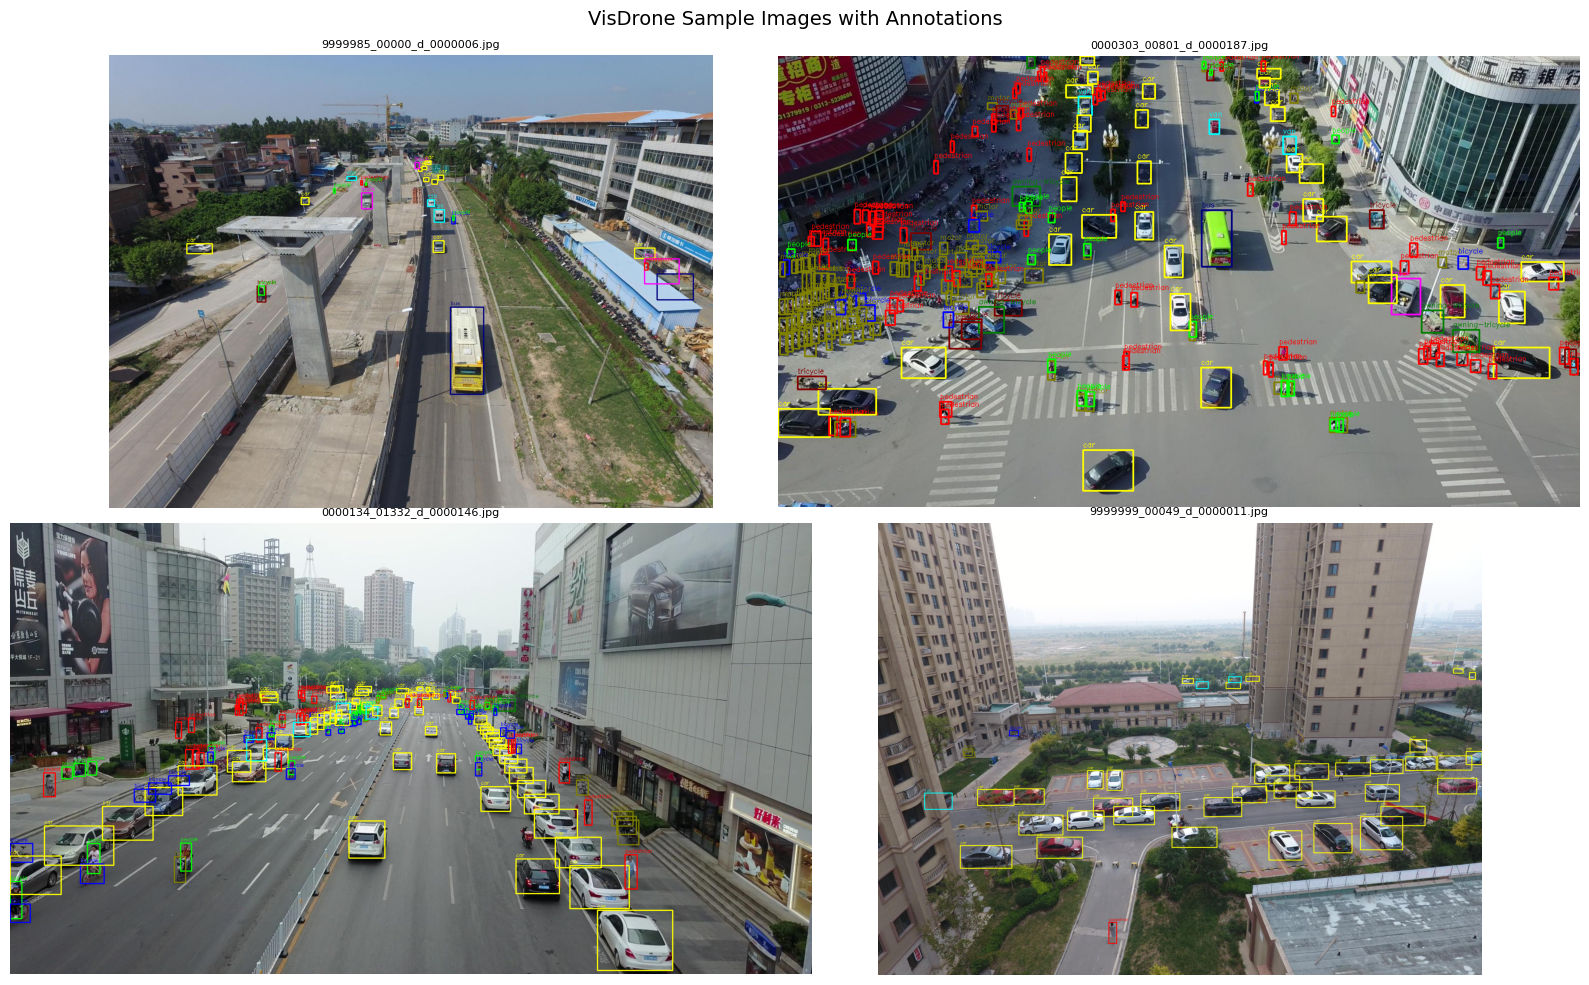

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import random

train_path = "/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train"

# Class names and colors
class_names = ['pedestrian','people','bicycle','car','van','truck','tricycle','awning-tricycle','bus','motor']
colors = [(255,0,0),(0,255,0),(0,0,255),(255,255,0),(0,255,255),
          (255,0,255),(128,0,0),(0,128,0),(0,0,128),(128,128,0)]

def visualize_sample(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path) as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            cv2.rectangle(img, (x1,y1), (x2,y2), colors[cls], 2)
            cv2.putText(img, class_names[cls], (x1, y1-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, colors[cls], 1)
    return img

# Pick 4 random samples
import glob
img_files = sorted(glob.glob(train_path + "/images/*.jpg"))
random.seed(42)
samples = random.sample(img_files, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, img_path in zip(axes.flatten(), samples):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    img = visualize_sample(img_path, label_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=8)

plt.suptitle("VisDrone Sample Images with Annotations", fontsize=14)
plt.tight_layout()
plt.show()

## Cell 6 — Dataset Statistics
Analyse class distribution and bounding box size distribution
across train and val splits. The bounding box size histogram
is the most important chart here — it shows what fraction
of objects are tiny (relative area < 0.01), which directly
explains why human detection is harder than car detection.

Analyzing dataset...
Train images: 6471 | Val images: 548


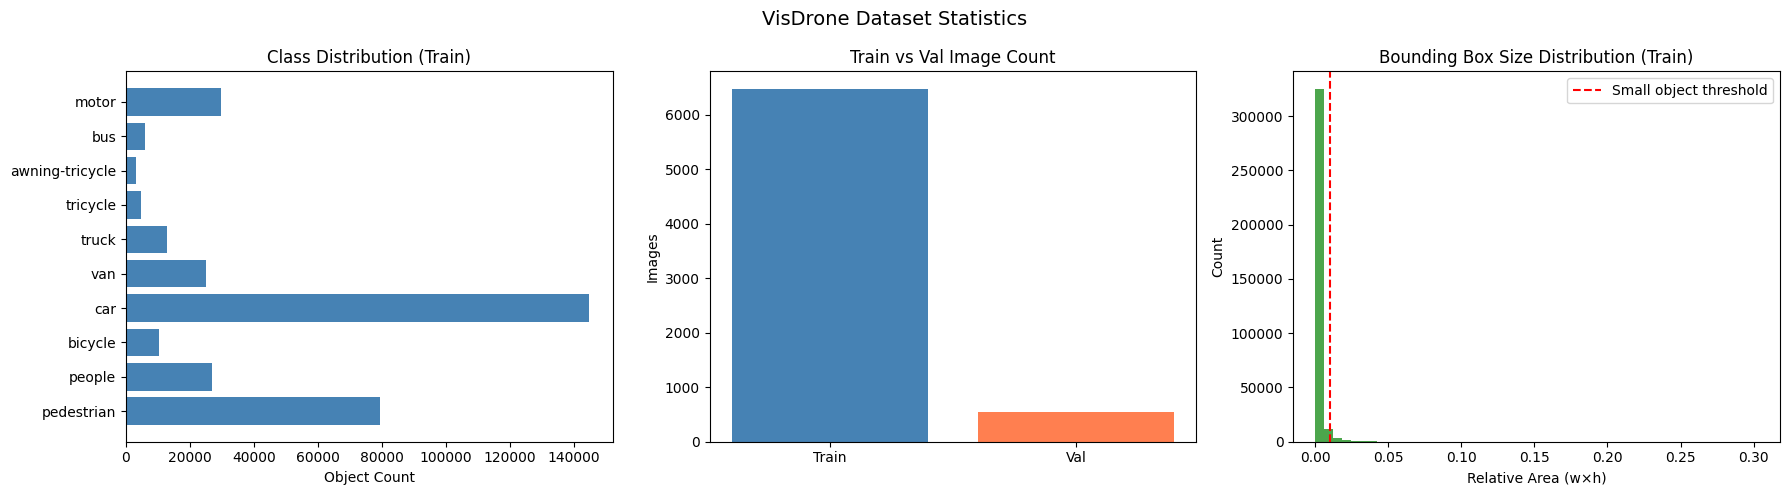


--- Key Observations ---
Most common class: car (144867 instances)
% of tiny objects (area < 0.01): 97.5%


In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

class_names = ['pedestrian','people','bicycle','car','van',
               'truck','tricycle','awning-tricycle','bus','motor']

train_path = "/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train"
val_path   = "/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val"

def get_stats(split_path):
    label_files = glob.glob(split_path + "/labels/*.txt")
    class_counts = Counter()
    box_sizes = []

    for lf in label_files:
        with open(lf) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls = int(parts[0])
                w, h = float(parts[3]), float(parts[4])
                class_counts[cls] += 1
                box_sizes.append(w * h)  # relative area

    return class_counts, box_sizes, len(label_files)

print("Analyzing dataset...")
train_counts, train_sizes, train_imgs = get_stats(train_path)
val_counts,   val_sizes,   val_imgs   = get_stats(val_path)

print(f"Train images: {train_imgs} | Val images: {val_imgs}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution (train)
labels = [class_names[i] for i in sorted(train_counts)]
values = [train_counts[i] for i in sorted(train_counts)]
axes[0].barh(labels, values, color='steelblue')
axes[0].set_title("Class Distribution (Train)")
axes[0].set_xlabel("Object Count")

# 2. Train vs Val image count
axes[1].bar(["Train", "Val"], [train_imgs, val_imgs], color=['steelblue','coral'])
axes[1].set_title("Train vs Val Image Count")
axes[1].set_ylabel("Images")

# 3. Bounding box size distribution
axes[2].hist(train_sizes, bins=50, color='green', alpha=0.7)
axes[2].set_title("Bounding Box Size Distribution (Train)")
axes[2].set_xlabel("Relative Area (w×h)")
axes[2].set_ylabel("Count")
axes[2].axvline(x=0.01, color='red', linestyle='--', label='Small object threshold')
axes[2].legend()

plt.suptitle("VisDrone Dataset Statistics", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\n--- Key Observations ---")
print(f"Most common class: {class_names[train_counts.most_common(1)[0][0]]} ({train_counts.most_common(1)[0][1]} instances)")
print(f"% of tiny objects (area < 0.01): {sum(1 for s in train_sizes if s < 0.01) / len(train_sizes) * 100:.1f}%")

## Cell 7 — Class Filtering & Remapping to YOLO Format
The most critical preprocessing step in this notebook.

Remapping logic:
- pedestrian (0) → human (0)
- people (1)     → human (0)  ← crowd annotations, same semantic meaning
- car (3)        → car (1)
- all others     → dropped

Images with zero valid labels after filtering are also
dropped to avoid training on empty annotations.
Coordinates are converted from VisDrone format to
normalised YOLO centre-based format: class cx cy w h

In [ ]:
import os
import glob
import shutil
from tqdm import tqdm

# --- Paths ---
BASE     = "/kaggle/input/visdrone-dataset/VisDrone_Dataset"
OUT_BASE = "/content/visdrone_yolo"

SPLITS = {
    "train": f"{BASE}/VisDrone2019-DET-train",
    "val":   f"{BASE}/VisDrone2019-DET-val",
}

# Class remapping
REMAP = {0: 0, 1: 0, 3: 1}  # pedestrian→human, people→human, car→car

# --- Create output folders ---
for split in SPLITS:
    os.makedirs(f"{OUT_BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUT_BASE}/labels/{split}", exist_ok=True)

# --- Process each split ---
stats = {}
for split, split_path in SPLITS.items():
    img_files = sorted(glob.glob(f"{split_path}/images/*.jpg"))
    kept_images = 0
    kept_labels = 0
    skipped_images = 0

    for img_path in tqdm(img_files, desc=f"Processing {split}"):
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = f"{split_path}/labels/{base_name}.txt"

        if not os.path.exists(label_path):
            continue

        # Filter and remap labels
        new_lines = []
        with open(label_path) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls = int(parts[0])
                if cls in REMAP:
                    new_cls = REMAP[cls]
                    new_lines.append(f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}")

        # Only keep images that have at least one target object
        if len(new_lines) == 0:
            skipped_images += 1
            continue

        # Copy image
        shutil.copy(img_path, f"{OUT_BASE}/images/{split}/{base_name}.jpg")

        # Write filtered label
        with open(f"{OUT_BASE}/labels/{split}/{base_name}.txt", "w") as f:
            f.write("\n".join(new_lines))

        kept_images += 1
        kept_labels += len(new_lines)

    stats[split] = {
        "images": kept_images,
        "labels": kept_labels,
        "skipped": skipped_images
    }

# --- Summary ---
print("\n✅ Dataset preparation complete!")
print(f"\n{'Split':<8} {'Images':<10} {'Objects':<10} {'Skipped':<10}")
print("-" * 40)
for split, s in stats.items():
    print(f"{split:<8} {s['images']:<10} {s['labels']:<10} {s['skipped']:<10}")

Processing val: 100%|██████████| 548/548 [00:05<00:00, 97.03it/s]


✅ Dataset preparation complete!

Split    Images     Objects    Skipped   
----------------------------------------
train    6468       251263     3         
val      548        28033      0         


## Cell 8 — Filtered Dataset Verification
Verify the remapped dataset looks correct before saving.
We check class distribution in both splits and visualise
sample images with the new 2-class labels to confirm
the remapping worked as expected.
Green = human, Yellow = car.

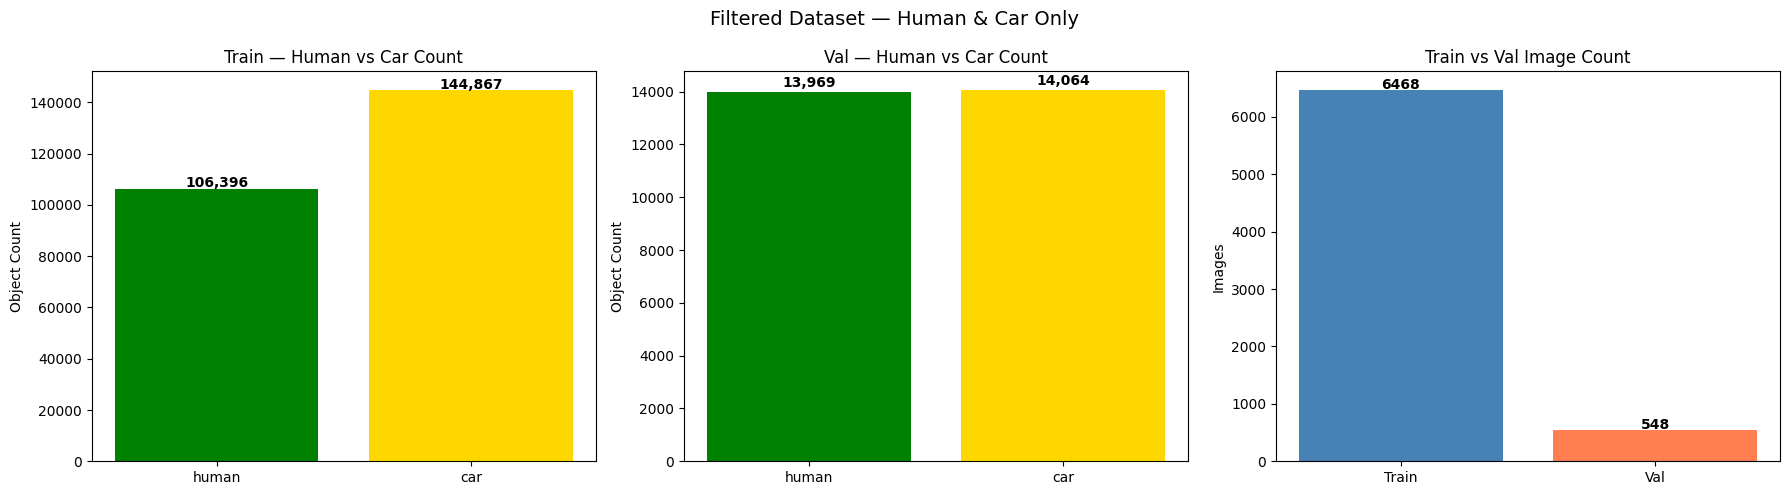

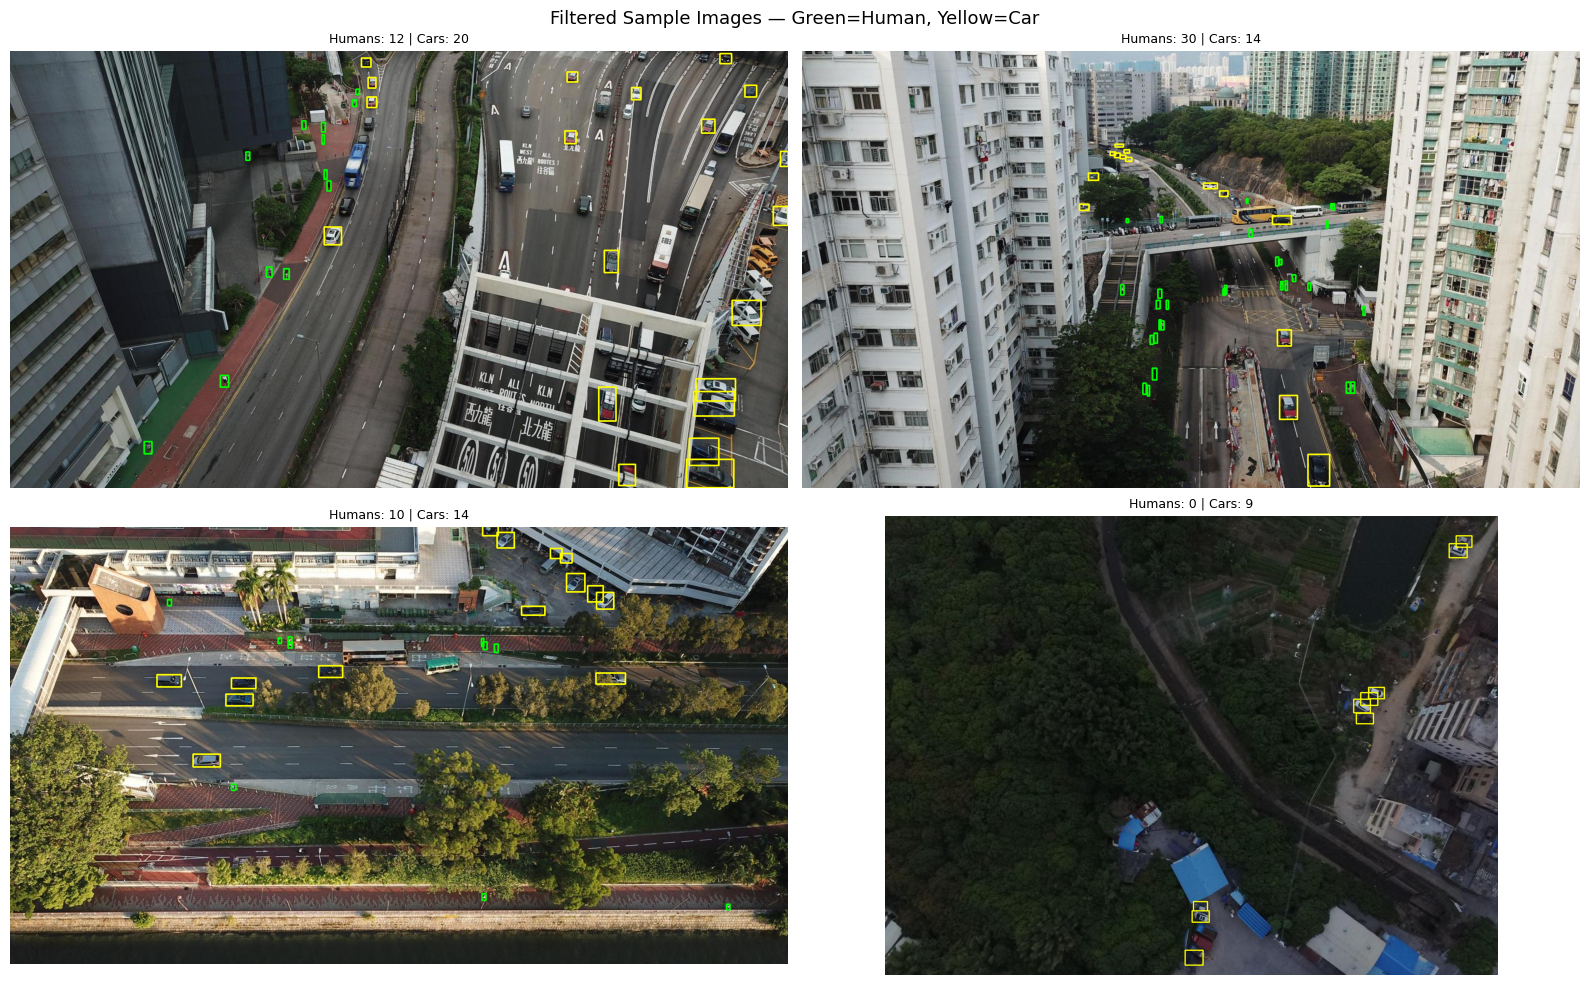


--- Summary ---
Train: 6468 images | 106,396 humans | 144,867 cars
Val:   548 images | 13,969 humans | 14,064 cars


In [ ]:
import glob
import matplotlib.pyplot as plt
from collections import Counter
import cv2
import random
import os

OUT_BASE = "/content/visdrone_yolo"
class_names = ['human', 'car']
colors = [(0, 255, 0), (255, 255, 0)]  # green=human, yellow=car

# --- Count class distribution ---
train_labels = glob.glob(f"{OUT_BASE}/labels/train/*.txt")
val_labels   = glob.glob(f"{OUT_BASE}/labels/val/*.txt")

def count_classes(label_files):
    counter = Counter()
    for lf in label_files:
        with open(lf) as f:
            for line in f.readlines():
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter

train_counts = count_classes(train_labels)
val_counts   = count_classes(val_labels)

# --- Plot 1: Class distribution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = [class_names[i] for i in range(2)]
train_vals = [train_counts[i] for i in range(2)]
val_vals   = [val_counts[i] for i in range(2)]

axes[0].bar(x, train_vals, color=['green','gold'])
axes[0].set_title("Train — Human vs Car Count")
axes[0].set_ylabel("Object Count")
for i, v in enumerate(train_vals):
    axes[0].text(i, v + 500, f"{v:,}", ha='center', fontweight='bold')

axes[1].bar(x, val_vals, color=['green','gold'])
axes[1].set_title("Val — Human vs Car Count")
axes[1].set_ylabel("Object Count")
for i, v in enumerate(val_vals):
    axes[1].text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')

# Train vs Val image count
axes[2].bar(["Train", "Val"], [len(train_labels), len(val_labels)], color=['steelblue','coral'])
axes[2].set_title("Train vs Val Image Count")
axes[2].set_ylabel("Images")
for i, v in enumerate([len(train_labels), len(val_labels)]):
    axes[2].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle("Filtered Dataset — Human & Car Only", fontsize=14)
plt.tight_layout()
plt.show()

# --- Plot 2: Sample filtered images ---
img_files = sorted(glob.glob(f"{OUT_BASE}/images/train/*.jpg"))
random.seed(99)
samples = random.sample(img_files, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, img_path in zip(axes.flatten(), samples):
    base = os.path.splitext(os.path.basename(img_path))[0]
    label_path = f"{OUT_BASE}/labels/train/{base}.txt"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    human_count = 0
    car_count = 0
    with open(label_path) as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            color = (0,255,0) if cls == 0 else (255,255,0)
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
            if cls == 0: human_count += 1
            else: car_count += 1
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"Humans: {human_count} | Cars: {car_count}", fontsize=9)

plt.suptitle("Filtered Sample Images — Green=Human, Yellow=Car", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n--- Summary ---")
print(f"Train: {len(train_labels)} images | {train_counts[0]:,} humans | {train_counts[1]:,} cars")
print(f"Val:   {len(val_labels)} images | {val_counts[0]:,} humans | {val_counts[1]:,} cars")

## Cell 9 — Save Filtered Dataset to Google Drive
Zip and transfer the filtered dataset to Drive for
persistent storage across sessions. Zipping is essential —
copying 6,000+ individual files to Drive one by one
is extremely slow and prone to timeout errors.
After this cell completes, Notebook 1 is fully done.

In [ ]:
from google.colab import drive
import os
import shutil

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Create project folder in Drive
DRIVE_PROJECT = '/content/drive/MyDrive/Antlings_Drone_Project'
os.makedirs(DRIVE_PROJECT, exist_ok=True)
print(f"✅ Drive folder ready: {DRIVE_PROJECT}")

# Step 3: Zip the filtered dataset
# Zipping is critical — copying 6000+ files individually is extremely slow
print("⏳ Zipping filtered dataset (this may take 2–3 minutes)...")
!zip -q -r /content/visdrone_yolo.zip /content/visdrone_yolo
print("✅ Zip complete!")

# Step 4: Copy zip to Drive
print("⏳ Copying to Google Drive...")
shutil.copy('/content/visdrone_yolo.zip', DRIVE_PROJECT)
print("✅ Dataset saved to Drive!")

# Step 5: Verify the file is actually there
size_mb = os.path.getsize(f"{DRIVE_PROJECT}/visdrone_yolo.zip") / (1024 * 1024)
print(f"\n--- Verification ---")
print(f"File: {DRIVE_PROJECT}/visdrone_yolo.zip")
print(f"Size: {size_mb:.1f} MB")
print(f"\n🎯 Colab 1 complete. Safe to close.")

Mounted at /content/drive
✅ Drive folder ready: /content/drive/MyDrive/Antlings_Drone_Project
⏳ Zipping filtered dataset (this may take 2–3 minutes)...
✅ Zip complete!
⏳ Copying to Google Drive...
✅ Dataset saved to Drive!

--- Verification ---
File: /content/drive/MyDrive/Antlings_Drone_Project/visdrone_yolo.zip
Size: 1555.1 MB

🎯 Colab 1 complete. Safe to close.
